In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load diabetes dataset
diabetes = load_diabetes()

# Create DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Add target column
df['Disease_Progression'] = diabetes.target

# Show first 5 rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Disease_Progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  442 non-null    float64
 1   sex                  442 non-null    float64
 2   bmi                  442 non-null    float64
 3   bp                   442 non-null    float64
 4   s1                   442 non-null    float64
 5   s2                   442 non-null    float64
 6   s3                   442 non-null    float64
 7   s4                   442 non-null    float64
 8   s5                   442 non-null    float64
 9   s6                   442 non-null    float64
 10  Disease_Progression  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Disease_Progression
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [5]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [6]:
# Fill missing values if any
df.fillna(df.mean(), inplace=True)

In [7]:
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(df.iloc[:, :-1])

print("Feature scaling completed")

Feature scaling completed


In [8]:
# Single feature (BMI)
X = df[['bmi']]

# Target
y = df['Disease_Progression']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
simple_model = LinearRegression()

simple_model.fit(X_train, y_train)

# Predictions
y_pred_simple = simple_model.predict(X_test)

In [9]:
mse = mean_squared_error(y_test, y_pred_simple)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression")

print("MSE:", mse)

print("RMSE:", rmse)

print("R² Score:", r2)

Simple Linear Regression
MSE: 4061.8259284949268
RMSE: 63.73245584860925
R² Score: 0.23335039815872138


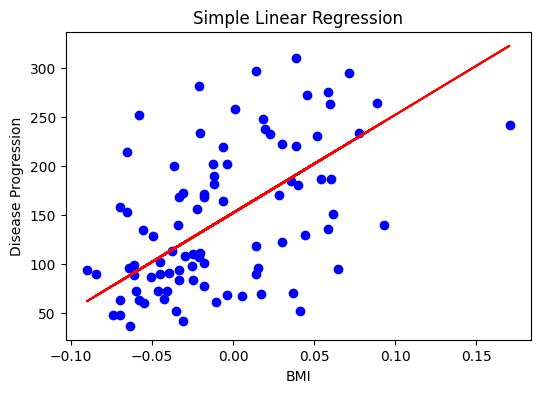

In [10]:
plt.figure(figsize=(6,4))

plt.scatter(X_test, y_test, color='blue')

plt.plot(X_test, y_pred_simple, color='red')

plt.xlabel("BMI")

plt.ylabel("Disease Progression")

plt.title("Simple Linear Regression")

plt.show()

In [11]:
# All features
X = df.iloc[:, :-1]

# Target
y = df['Disease_Progression']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
multi_model = LinearRegression()

multi_model.fit(X_train, y_train)

# Predictions
y_pred_multi = multi_model.predict(X_test)

In [12]:
mse = mean_squared_error(y_test, y_pred_multi)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_multi)

print("Multiple Linear Regression")

print("MSE:", mse)

print("RMSE:", rmse)

print("R² Score:", r2)

Multiple Linear Regression
MSE: 2900.193628493482
RMSE: 53.85344583676593
R² Score: 0.4526027629719195


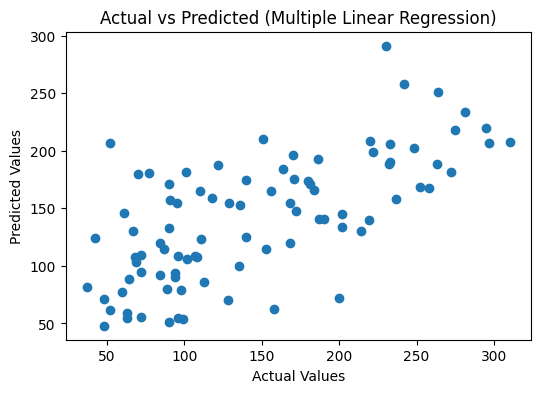

In [13]:
plt.figure(figsize=(6,4))

plt.scatter(y_test, y_pred_multi)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted (Multiple Linear Regression)")

plt.show()